## Packages


In [2]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from package_sampling.sampling import up_tille, up_brewer, up_systematic, up_max_entropy
from package_sampling.utils import inclusion_probabilities


### Python

In [5]:
# !pip install -q git+https://github.com/mehdimhb/geometric-sampling@dev
# !pip install git+https://github.com/mehdimhb/geometric-sampling@legacy-measure

In [6]:
from rpy2.robjects.packages import importr


In [7]:
%load_ext rpy2.ipython

In [8]:
import matplotlib as mpl
import numpy as np
from rpy2.robjects import r, numpy2ri
import rpy2.robjects as ro
from matplotlib import pyplot as plt
from itertools import combinations
from collections import OrderedDict
import pandas as pd
from tqdm import tqdm
from tqdm.contrib import tenumerate
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import graphical_sampling as gs
rng = gs.random.rng()

In [9]:
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter

with localconverter(ro.default_converter + numpy2ri.converter):
    # Any code that needs to talk to R goes inside this block
    rng = gs.random.rng() 

### R

In [10]:
# %%R

# # 1. Set R to use pre-compiled binaries for Ubuntu 24.04
# # This makes installation fast and error-free
# options(repos = c(CRAN = "https://packagemanager.posit.co/cran/__linux__/noble/latest"))

# # 2. Define the list of remaining packages
# # - spsurvey: EPA's GRTS implementation
# # - BalancedSampling: LPM (Local Pivotal Method) and Cube method
# # - sampling: General survey sampling functions
# # - WaveSampling: Weakly Associated Vectors (WAV) method
# # - spcosa: k-means based stratification
# pkgs <- c("spsurvey", "BalancedSampling", "sampling", "WaveSampling", "spcosa")

# # 3. Install them all at once
# install.packages(pkgs, dependencies = TRUE)

# # 4. Load and Verify
# # We loop through them to make sure each one loads correctly
# for (pkg in pkgs) {
#     if (require(pkg, character.only = TRUE)) {
#         message(paste("✅ Success:", pkg, "is installed and loaded."))
#     } else {
#         message(paste("❌ Error: Could not load", pkg))
#     }
# }

In [11]:
%%R

# --- Core Spatial Data ---
library(sf)               # Simple Features (Geometry handling)

# --- Sampling Design Packages ---
library(spbal)            # BAS, HIP, Halton Frames (Robertson et al.)
library(spsurvey)         # GRTS (Generalized Random Tessellation Stratified)
library(BalancedSampling) # LPM (Local Pivotal Method) & Cube method
library(WaveSampling)     # WAV (Weakly Associated Vectors)

# --- Stratification & Dependencies ---
library(rJava)            # Low-level Java interface (Required for spcosa)
library(spcosa)           # Spatial Coverage Sampling (k-means stratification)
library(sampling)         # General survey algorithms (UPpivotal, inclusion probs)

# --- Verification ---
print("✅ Success! All spatial sampling packages are loaded and ready.")

[1] "✅ Success! All spatial sampling packages are loaded and ready."


Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE
Loading required package: survey
Loading required package: grid
Loading required package: Matrix
Loading required package: survival

Attaching package: ‘survey’

The following object is masked from ‘package:graphics’:

    dotchart


Attaching package: ‘sampling’

The following objects are masked from ‘package:survival’:

    cluster, strata



## Measures and Sampling Design

### Measures

In [12]:
def scores(coords, probs, n, N, sample_idx, split_size, density_measure=None):
    assert len(coords) == len(probs) == N
    assert len(sample_idx) == n
    sample_mask = np.zeros(N, dtype=int)
    sample_mask[sample_idx] = 1

    ro.globalenv['sample_mask'] = sample_mask
    ro.globalenv['sample_idx'] = sample_idx + 1
    ro.globalenv['coords'] = coords
    ro.globalenv['probs'] = probs
    ro.globalenv['n'] = n
    ro.globalenv['N'] = N
    #ro.globalenv['split_size'] = split_size


    r_code = """
W <- wpik(coords,probs)
W <- W - diag(diag(W))
diag(W) <- 0  # Ensure W has zero diagonal


ib_value <- tryCatch({
  IB(W, sample_mask)  # Moran's Index
}, error = function(e) {
  Inf
})

sb_value <- tryCatch({
  sb(probs, coords, sample_idx)  # Spatial balance
}, error = function(e) {
  Inf
})

sblb_value <- tryCatch({
  sblb(probs, coords, sample_idx)  # Spatial balance using local balance
}, error = function(e) {
  Inf
})
"""
    ro.r(r_code)
    IB_value = ro.r("ib_value")[0]
    SB_value = ro.r("sb_value")[0]
    SBLB_value = ro.r("sblb_value")[0]
    if density_measure is None:
      scaled_coords = (coords - np.min(coords, axis=0)) / np.ptp(coords, axis=0)
      density_measure = gs.measure.Density(scaled_coords, probs, n, split_size=0.001)
    scores, _ = density_measure.score(sample_idx.reshape(1, -1))
    return scores[0][0], SB_value, IB_value, SBLB_value


### Sampling Designs

In [13]:
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter

# Define the converter to be used in context managers
# We combine the default R converter with the NumPy converter
conv = ro.default_converter + numpy2ri.converter

def _create_sf_points_in_r(coords):
    """Helper to convert numpy coords to an R 'sf' object."""
    # We must use the converter here because we are passing a numpy array 'coords' to R
    with localconverter(conv):
        ro.globalenv['coords'] = coords
        r_code = """
        library(sf)
        # Ensure coords is treated as a matrix/data.frame in R
        df <- data.frame(x = coords[,1], y = coords[,2])
        pts <- st_as_sf(df, coords = c("x", "y"))
        """
        ro.r(r_code)
    return ro.globalenv['pts']

def local_pivotal_samples(coords, probs, n, num_samples):
    samples_idx = np.zeros((num_samples, n), dtype=int)
    
    with localconverter(conv):
        ro.globalenv['coords'] = coords
        ro.globalenv['probs'] = probs
        
        for i in range(num_samples):
            # lpm2 is generally preferred over lpm in BalancedSampling
            r_code = "s <- BalancedSampling::lpm2(probs, coords)" 
            ro.r(r_code)
            # Result is 1-based index from R
            sample_idx = np.array(list(ro.r("s"))) - 1
            samples_idx[i] = sample_idx

    return samples_idx

def k_means_samples(coords, probs, n, num_samples, n_zones):
    # Placeholder - assumes gs package exists in your environment
    return gs.sampling.KMeansSpatialSamplingSimple(coords, probs, n=n, n_zones=n_zones, tolerance=2, split_size=0.001).sample(num_samples)

def random_samples(coords, probs, n, num_samples):
    # Placeholder
    return gs.sampling.RandomSampling(coords, probs, n=n).sample(num_samples)

def upmaxentropy_samples(probs, num_samples):
    n = int(round(np.sum(probs)))
    samples_idx = np.zeros((num_samples, n), dtype=int)
    
    with localconverter(conv):
        ro.globalenv['probs'] = probs
        for i in range(num_samples):
            r_code = """
            library(sampling)
            mask <- UPmaxentropy(probs)
            """
            ro.r(r_code)
            mask = np.array(ro.r("mask"))
            # Ensure boolean type
            if mask.dtype != np.bool_:
                mask = mask.astype(bool)
            sample_idx = np.where(mask)[0]
            samples_idx[i] = sample_idx

    return samples_idx

def wave_samples(coords, probs, n, num_samples):
    samples_idx = np.zeros((num_samples, n), dtype=int)
    
    with localconverter(conv):
        ro.globalenv['coords'] = coords
        ro.globalenv['probs'] = probs
        for i in range(num_samples):
            r_code = """
            library(WaveSampling)
            wave_mask <- wave(coords, probs)
            """
            ro.r(r_code)
            mask = np.array(ro.r("wave_mask"))
            if mask.dtype != np.bool_:
                mask = mask.astype(bool)
            sample_idx = np.where(mask)[0]
            samples_idx[i] = sample_idx

    return samples_idx

def spcosa_samples(coords, n, num_samples):
    """
    Equal Probability: Uses spcosa (Spatial Coverage Sampling).
    """
    samples_idx = np.zeros((num_samples, n), dtype=int)
    
    with localconverter(conv):
        ro.globalenv['coords'] = coords
        # Pre-setup data once
        ro.r("""
        library(spcosa)
        df <- data.frame(x = coords[,1], y = coords[,2])
        coordinates(df) <- ~x + y
        gridded(df) <- TRUE 
        """)
        
        for i in range(num_samples):
            r_code = f"""
            set.seed({np.random.randint(1, 1e9)})
            stratification <- stratify(df, nStrata = {n}, nTry = 10)
            samples <- spsample(stratification)
            whichrow <- as.integer(rownames(as(samples, "data.frame")))
            """
            ro.r(r_code)
            sample_idx = np.array(ro.r("whichrow")) - 1
            samples_idx[i] = sample_idx
            
    return samples_idx

def hip_samples(coords, n, num_samples):
    """
    Equal Probability: Uses spbal::HIP (Halton Iterative Partitioning).
    """
    # Create sf object (handles converter internally)
    _create_sf_points_in_r(coords)
    
    samples_idx = np.zeros((num_samples, n), dtype=int)
    
    with localconverter(conv):
        for i in range(num_samples):
            r_code = f"""
            library(spbal)
            set.seed({np.random.randint(1, 1e9)})
            res <- HIP(population = pts, n = {n})
            s_idx <- as.integer(rownames(res$sample))
            """
            ro.r(r_code)
            sample_idx = np.array(ro.r("s_idx")) - 1
            samples_idx[i] = sample_idx
            
    return samples_idx

def grts_samples(coords, n, num_samples, is_EP=True, probs=None):
    """
    Uses spsurvey::grts.
    """
    _create_sf_points_in_r(coords)
    
    # Handle Unequal Probability setup
    if not is_EP and probs is not None:
        with localconverter(conv):
            ro.globalenv['probs'] = probs
            ro.r("pts$probs <- probs")
        aux_arg = ', aux_var = "probs"'
    else:
        aux_arg = ""

    samples_idx = np.zeros((num_samples, n), dtype=int)

    with localconverter(conv):
        for i in range(num_samples):
            r_code = f"""
            library(spsurvey)
            set.seed({np.random.randint(1, 1e9)})
            design_res <- grts(sframe = pts, n_base = {n} {aux_arg})
            
            # Extract indices safely using row names
            s_idx <- as.numeric(rownames(design_res$sites_base))
            """
            try:
                ro.r(r_code)
                sample_idx = np.array(ro.r("s_idx")) - 1
                samples_idx[i] = sample_idx
            except Exception as e:
                print(f"GRTS iteration {i} failed: {e}")
            
    return samples_idx


def find_samples(coords, probs, n, num_samples, designs="all"):
    """
    Orchestrates sampling based on EP vs UP capabilities.
    """
    
    # 1. Determine Probability Mode (EP vs UP)
    is_EP = np.allclose(probs, probs[0]) and np.isclose(np.sum(probs), n)
    
    mode_str = "Equal Probability (EP)" if is_EP else "Unequal Probability (UP)"
    print(f"Sampling Mode Detected: {mode_str}")

    # 2. Define Capabilities
    methods_map = {
        "Rand": (True,  True,  lambda: random_samples(coords, probs, n, num_samples)),
        "Lopi": (True,  True,  lambda: local_pivotal_samples(coords, probs, n, num_samples)),
        "Wave": (True,  True,  lambda: wave_samples(coords, probs, n, num_samples)),
        "Nmcs": (True,  True,  lambda: k_means_samples(coords, probs, n, num_samples, (2, 2))),
        "Spco": (True,  False, lambda: spcosa_samples(coords, n, num_samples)),
        "HIP":  (True,  False, lambda: hip_samples(coords, n, num_samples)),
        "Maxe": (False, True,  lambda: upmaxentropy_samples(probs, num_samples)),
        "GRTS": (True,  False, lambda: grts_samples(coords, n, num_samples, is_EP, probs)), 
    }

    # 3. Filter Designs
    results = {}
    target_designs = list(methods_map.keys()) if designs == "all" else designs
    
    for name in target_designs:
        if name not in methods_map:
            print(f"Warning: Design '{name}' not recognized.")
            continue
            
        supports_EP, supports_UP, func = methods_map[name]
        
        # Check eligibility
        if (is_EP and supports_EP) or (not is_EP and supports_UP):
            print(f"Running {name}...")
            results[name] = func()
        else:
            print(f"Skipping {name} (Not applicable for {mode_str})")

    return results

## Data, Coordinates and Inclusions

### Generating New Data

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# --- SEEDING for reproducibility ---
np.random.seed(42)

# --- PARAMS ---
n = 10
n_clusters = n                         # Target sample size
grid_size = 20                  # For grid, grid_size^2 points → 400 total
num_clusters = 5               # For clustered
cluster_std = 0.05
swiss_csv = '/home/divar/projects/geometric-sampling/swiss.csv'
swiss_shp = '/home/divar/Downloads/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp'

# -- You must define/provide these based on your project --
# rng.grid_coordinates(shape), rng.random_coordinates(shape), rng.cluster_coordinates, etc.
# rng.equal_probabilities(n, N), rng.unequal_probabilities(n, N)
# inclusion_probabilities()
# gs.sampling.KMeansSpatialSamplingSimple  # for making pop object with plot()

# --- 1. Setup holders for all coordinates/probs/populations ---
populations = {}
probabilities = {}
pop_objs = {}

# --- 2. REGULAR GRID ---
coords_grid = rng.grid_coordinates((grid_size, 2))
coords_grid = coords_grid[np.lexsort((coords_grid[:, 1], coords_grid[:, 0]))]
N_grid = coords_grid.shape[0]
probs_grid_eq = rng.equal_probabilities(n, N_grid)
probs_grid_uneq = np.sort(rng.unequal_probabilities(n, N_grid))

populations['grid'] = coords_grid
probabilities['grid_eq'] = probs_grid_eq
probabilities['grid_uneq'] = probs_grid_uneq

# --- 3. RANDOM ---
coords_rand = rng.random_coordinates((N_grid, 2))
coords_rand = coords_rand[np.lexsort((coords_rand[:, 1], coords_rand[:, 0]))]
probs_rand_eq = rng.equal_probabilities(n, N_grid)
probs_rand_uneq = np.sort(rng.unequal_probabilities(n, N_grid))

populations['random'] = coords_rand
probabilities['random_eq'] = probs_rand_eq
probabilities['random_uneq'] = probs_rand_uneq

# --- 4. CLUSTERED ---
coords_clust = rng.cluster_coordinates(num_clusters, cluster_std, (N_grid, 2))
coords_clust = coords_clust[np.lexsort((coords_clust[:, 1], coords_clust[:, 0]))]
probs_clust_eq = rng.equal_probabilities(n, N_grid)
probs_clust_uneq = np.sort(rng.unequal_probabilities(n, N_grid))

populations['clust'] = coords_clust
probabilities['clust_eq'] = probs_clust_eq
probabilities['clust_uneq'] = probs_clust_uneq

# --- 5. SWISS ---
swiss_df = pd.read_csv(swiss_csv)
coords_swiss = swiss_df[['COORD_X', 'COORD_Y']].to_numpy()
N_swiss = coords_swiss.shape[0]
area = swiss_df['AREA'].clip(1, 150)
probs_swiss_eq = rng.equal_probabilities(n, N_swiss)
probs_swiss_uneq = inclusion_probabilities(area, n)

populations['swiss'] = coords_swiss
probabilities['swiss_eq'] = probs_swiss_eq
probabilities['swiss_uneq'] = probs_swiss_uneq

# ---- 6. Create pop objects (e.g. for your plotting/class methods, using equal probs for now) ----
for key, coords in populations.items():
    if key == 'swiss':
        hard = gs.sampling.KMeansSpatialSamplingSimple(
            coords, probabilities[f'{key}_eq'], n=n, n_zones=(2, 2), tolerance=3, split_size=.001)
        pop_objs[f'{key}_eq'] = hard.popu
        hard = gs.sampling.KMeansSpatialSamplingSimple(
            coords, probabilities[f'{key}_uneq'], n=n, n_zones=(2, 2), tolerance=3, split_size=.001)
        pop_objs[f'{key}_uneq'] = hard.popu
    else:
        hard = gs.sampling.KMeansSpatialSamplingSimple(
            coords, probabilities[f'{key}_eq'], n=n, n_zones=(2, 2), tolerance=3, split_size=.001)
        pop_objs[f'{key}_eq'] = hard.popu
        hard = gs.sampling.KMeansSpatialSamplingSimple(
            coords, probabilities[f'{key}_uneq'], n=n, n_zones=(2, 2), tolerance=3, split_size=.0001)
        pop_objs[f'{key}_uneq'] = hard.popu

# ---- 7. Load Swiss map outline for background ----
world = gpd.read_file(swiss_shp)
swiss_map = world[world['ADMIN'] == 'Switzerland'].to_crs(epsg=2056)


# ==== Populations/coordinat/probs are stored in 'populations' and 'probabilities' dicts for later use ====

FileNotFoundError: [Errno 2] No such file or directory: '/home/divar/projects/geometric-sampling/swiss.csv'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull, QhullError
from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained

# -- Your custom spatial sampling class, plot_convex_hull function, etc, must be defined

# ----- Load CSVs into populations/probabilities -----
pop_files = {
    'grid_eq':  'grid_eq.csv',
    'grid_uneq': 'grid_uneq.csv',
    'random_eq': 'random_eq.csv',
    'random_uneq': 'random_uneq.csv',
    'clust_eq': 'clust_eq.csv',
    'clust_uneq': 'clust_uneq.csv',
}
populations = {}
probabilities = {}
for key, fname in pop_files.items():
    df = pd.read_csv(f"data_samples/{fname}")
    # E.g. populations['grid']=... only once per type; for safety use eq version
    popname = key.split('_')[0]
    if popname not in populations:
        populations[popname] = df[['x','y']].values
    probabilities[key] = df['prob'].values

# --------- Sampling objects for first two rows ----------
n = 4                     # or whatever n you used
pop_objs = {}
for popname, coords in populations.items():
    key_eq = f'{popname}_eq'
    key_uneq = f'{popname}_uneq'
    # You use your spatial-sampling class here
    # Adjust tolerance and split_size as needed!
    hard = gs.sampling.KMeansSpatialSamplingSimple(
        coords, probabilities[key_eq], n=n, n_zones=(2, 2), tolerance=3, split_size=.001)
    pop_objs[key_eq] = hard.popu
    hard = gs.sampling.KMeansSpatialSamplingSimple(
        coords, probabilities[key_uneq], n=n, n_zones=(2,2), tolerance=3, split_size=.0001)
    pop_objs[key_uneq] = hard.popu


### Loading Existing Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull, QhullError
from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained

# -- Your custom spatial sampling class, plot_convex_hull function, etc, must be defined

# ----- Load CSVs into populations/probabilities -----
pop_files = {
    'grid_eq':  'grid_eq.csv',
    'grid_uneq': 'grid_uneq.csv',
    'random_eq': 'random_eq.csv',
    'random_uneq': 'random_uneq.csv',
    'clust_eq': 'clust_eq.csv',
    'clust_uneq': 'clust_uneq.csv',
}
populations = {}
probabilities = {}
for key, fname in pop_files.items():
    df = pd.read_csv(f"data_samples/{fname}")
    # E.g. populations['grid']=... only once per type; for safety use eq version
    popname = key.split('_')[0]
    if popname not in populations:
        populations[popname] = df[['x','y']].values
    probabilities[key] = df['prob'].values

# --------- Sampling objects for first two rows ----------
n = 4                     # or whatever n you used
pop_objs = {}
for popname, coords in populations.items():
    key_eq = f'{popname}_eq'
    key_uneq = f'{popname}_uneq'
    # You use your spatial-sampling class here
    # Adjust tolerance and split_size as needed!
    hard = gs.sampling.KMeansSpatialSamplingSimple(
        coords, probabilities[key_eq], n=n, n_zones=(2, 2), tolerance=3, split_size=.001)
    pop_objs[key_eq] = hard.popu
    hard = gs.sampling.KMeansSpatialSamplingSimple(
        coords, probabilities[key_uneq], n=n, n_zones=(2,2), tolerance=3, split_size=.0001)
    pop_objs[key_uneq] = hard.popu


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull, QhullError
from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained

# -- Your custom spatial sampling class, plot_convex_hull function, etc, must be defined

# ----- Load CSVs into populations/probabilities -----
pop_files = {
    'swiss_eq':  'swiss_eq.csv',
    'swiss_uneq': 'swiss_uneq.csv',
}
populations = {}
probabilities = {}
for key, fname in pop_files.items():
    df = pd.read_csv(f"data_samples/{fname}")
    # E.g. populations['grid']=... only once per type; for safety use eq version
    popname = key.split('_')[0]
    if popname not in populations:
        populations[popname] = df[['x','y']].values
    probabilities[key] = df['prob'].values

# --------- Sampling objects for first two rows ----------
n = 10                     # or whatever n you used
pop_objs = {}
for popname, coords in populations.items():
    key_eq = f'{popname}_eq'
    key_uneq = f'{popname}_uneq'
    # You use your spatial-sampling class here
    # Adjust tolerance and split_size as needed!
    hard = gs.sampling.KMeansSpatialSamplingSimple(
        coords, probabilities[key_eq], n=n, n_zones=(2, 2), tolerance=3, split_size=.001)
    pop_objs[key_eq] = hard.popu
    hard = gs.sampling.KMeansSpatialSamplingSimple(
        coords, probabilities[key_uneq], n=n, n_zones=(2,2), tolerance=3, split_size=.0001)
    pop_objs[key_uneq] = hard.popu


#### Swiss sampling

In [ ]:
swiss_df = pd.read_csv('/home/divar/projects/geometric-sampling/swiss.csv')
coords = swiss_df[['COORD_X', 'COORD_Y']].to_numpy()
swiss_area_cliped = swiss_df['AREA'].clip(lower=1, upper=150)
N = len(coords)

probs = inclusion_probabilities(swiss_area_cliped, n)


### Gathering Data

In [ ]:
import pandas as pd
import os

folder = "data_samples"
os.makedirs(folder, exist_ok=True)

#   # diactivated to not overwrite some new results!
for name, pop in pop_objs.items():
    # Assuming pop.coords shape (N,2), pop.probs shape (N,)
    df = pd.DataFrame(pop.coords, columns=["x", "y"])
    df["prob"] = pop.probs
    filename = f"{name}.csv"
    df.to_csv(os.path.join(folder, filename), index=False)
    print(f"Saved {filename}")

Saved swiss_eq.csv
Saved swiss_uneq.csv


In [ ]:
df_coord_probs = pd.read_csv("data_samples/grid_eq.csv")
coords = df_coord_probs[["x", "y"]].values
probs = df_coord_probs["prob"].values

In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
folder = "data_samples"
os.makedirs(folder, exist_ok=True)
all_coords = []
all_probs = []
names = [
    "clust_eq", "clust_uneq",
    "grid_eq", "grid_uneq",
    "random_eq", "random_uneq"
]
names = [
    "swiss_uneq",
    ]
#names = ["random_uneq"]
for name in names:
    df = pd.read_csv(f"data_samples/{name}.csv")
    coords = df[["x", "y"]].values
    probs = df["prob"].values
    all_coords.append(coords)
    all_probs.append(probs)
print(sum(probs))
print(len(probs))
sample_cnt = 1000
columns = ["Method", "Density", "Voronoi", "Moran", "Local Balance"]

for coords, probs, name in zip(all_coords, all_probs, names):
    n = int(np.round(np.sum(probs)))
    N =len(probs)
    # Any code for one set, put here:
    sample_methods = find_samples(coords, probs, n, sample_cnt)
    scaled_coords = (coords - np.min(coords, axis=0)) / np.ptp(coords, axis=0)
    density_measure = gs.measure.Density(scaled_coords, probs, n, split_size=0.001)
    rows = np.array([
    [method, *scores(coords, probs, n, N, s, density_measure)]
    for method, samples in sample_methods.items()
    if samples is not None  # <----- add this
    for s in tqdm(samples, total=sample_cnt)
])
    df = pd.DataFrame(rows, columns=columns)
    df = df.astype({
        "Density": float,
        "Voronoi": float,
        "Moran": float,
        "Local Balance": float
    })
    filename = os.path.join(folder, f"results_{name}.csv")
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")

9.999999999999952
959


100%|██████████| 1000/1000 [2:50:57<00:00, 10.26s/it] 

Saved: data_samples/results_swiss_uneq.csv


In [22]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

folder = "data_samples"
os.makedirs(folder, exist_ok=True)

# List all _eq.csv data files for processing
data_files = [f for f in os.listdir(folder) if f.endswith("_eq.csv") and not f.startswith("results_")]

sample_cnt = 1000
columns = ["Method", "Density", "Voronoi", "Moran", "Local Balance"]

for data_file in data_files:
    # Set up base names
    case_name = data_file.replace(".csv", "")
    result_file = os.path.join(folder, f"results_{case_name}.csv")

    print(f"Processing: {data_file} -> {result_file}")
    # Load input data
    df = pd.read_csv(os.path.join(folder, data_file))
    coords = df[["x", "y"]].values
    probs = df["prob"].values
    n = int(np.round(np.sum(probs)))
    N = len(probs)

    # Your existing scoring infrastructure
    #scaled_coords = (coords - np.min(coords, axis=0)) / np.ptp(coords, axis=0)
    density_measure = gs.measure.Density(coords, probs, n, split_size=0.001)

    # Load or create results file
    if os.path.exists(result_file):
        df_results = pd.read_csv(result_file)
    else:
        df_results = pd.DataFrame(columns=columns)

    # Get only the two new methods for equal probability cases
    sample_methods = find_samples(coords, probs, n, sample_cnt, ep_mode="EP")

    for method in ["spcosa"]:
        samples = sample_methods.get(method)
        if samples is not None:
            new_rows = np.array([
                [method, *scores(coords, probs, n, N, s, density_measure)]
                for s in tqdm(samples, total=sample_cnt, desc=f"{method} - {case_name}")
            ])
            df_new = pd.DataFrame(new_rows, columns=columns)
            df_new = df_new.astype({
                "Density": float,
                "Voronoi": float,
                "Moran": float,
                "Local Balance": float
            })
            df_results = pd.concat([df_results, df_new], ignore_index=True)

    df_results.to_csv(result_file, index=False)
    print(f"Saved: {result_file}")

Processing: clust_eq.csv -> data_samples/results_clust_eq.csv


R[write to console]: Loading required package: rJava

R[write to console]: Error: package or namespace load failed for ‘rJava’:
 .onLoad failed in loadNamespace() for 'rJava', details:
  call: dyn.load(file, DLLpath = DLLpath, ...)
  error: unable to load shared object '/usr/lib/R/site-library/rJava/libs/rJava.so':
  libjvm.so: cannot open shared object file: No such file or directory

R[write to console]: Error: package ‘rJava’ could not be loaded



RRuntimeError: Error: package ‘rJava’ could not be loaded


In [ ]:
results_dict = {}

for name in names:
    df = pd.read_csv(os.path.join(folder, f"results_{name}.csv"))
    results_dict[name] = df

FileNotFoundError: [Errno 2] No such file or directory: 'data_samples/results_swiss_uneq.csv'

## Results

In [ ]:
df = results_dict["grid_eq"]

In [ ]:
%load_ext autoreload
%autoreload 2
import geometric_sampling as gs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Tables

Means

Describe

In [ ]:
#df.groupby("Method").std()
#df.groupby("Method").mean()
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
  display(df.groupby("Method").describe())

Density                                            \
                 count          mean           std           min   
Method                                                             
K-Means (1, 1)     5.0 -8.243072e-16  6.757714e-17 -8.575073e-16   
K-Means (2, 2)     5.0 -7.918254e-16  7.943882e-17 -8.632342e-16   
Local Pivotal      5.0 -1.908042e-01  2.005944e-01 -3.909999e-01   
Random             5.0 -2.143390e-01  3.898654e-01 -6.306073e-01   
UPmaxentropy       5.0 -3.773028e-01  2.155575e-01 -7.270992e-01   

                                                                        \
                         25%           50%           75%           max   
Method                                                                   
K-Means (1, 1) -8.575073e-16 -8.528520e-16 -8.501153e-16 -7.035541e-16   
K-Means (2, 2) -8.435283e-16 -8.417510e-16 -7.070593e-16 -7.035541e-16   
Local Pivotal  -3.362569e-01 -2.346140e-01 -1.008596e-01  1.087094e-01   
Random         -5.830634e-01 -1.872128e-01  9.101805e-02  2.381702e-01   
UPmaxentropy   -4.213662e-01 -3.157500e-01 -2.469151e-01 -1.753835e-01   

               Voronoi                                                    \
                 count      mean       std       min       25%       50%   
Method                                                                     
K-Means (1, 1)     5.0  0.129015  0.101276  0.012525  0.063400  0.102563   
K-Means (2, 2)     5.0  0.171154  0.079376  0.049250  0.162900  0.171600   
Local Pivotal      5.0  0.099983  0.088553  0.007550  0.019013  0.107700   
Random             5.0  0.215792  0.221698  0.032300  0.054950  0.178312   
UPmaxentropy       5.0  0.314650  0.091820  0.215163  0.235525  0.328963   

                                   Moran                                \
                     75%       max count      mean       std       min   
Method                                                                   
K-Means (1, 1)  0.214525  0.252063   5.0 -0.221298  0.053646 -0.287469   
K-Means (2, 2)  0.205506  0.266513   5.0 -0.211112  0.040810 -0.265425   
Local Pivotal   0.147600  0.218050   5.0 -0.106575  0.036547 -0.149541   
Random          0.229550  0.583850   5.0 -0.089686  0.061531 -0.171857   
UPmaxentropy    0.352850  0.440750   5.0 -0.058093  0.049809 -0.118767   

                                                       Local Balance  \
                     25%       50%       75%       max         count   
Method                                                                 
K-Means (1, 1) -0.258744 -0.222936 -0.178376 -0.158962           5.0   
K-Means (2, 2) -0.223750 -0.222950 -0.184131 -0.159305           5.0   
Local Pivotal  -0.129624 -0.105564 -0.094705 -0.053440           5.0   
Random         -0.123572 -0.073720 -0.071102 -0.008179           5.0   
UPmaxentropy   -0.102349 -0.043344 -0.013161 -0.012844           5.0   

                                                                            \
                    mean       std       min       25%       50%       75%   
Method                                                                       
K-Means (1, 1)  0.385465  0.163570  0.155799  0.302032  0.393549  0.518861   
K-Means (2, 2)  0.430794  0.106319  0.265230  0.411866  0.433078  0.501395   
Local Pivotal   0.326949  0.108931  0.207518  0.226604  0.336332  0.410812   
Random          0.471855  0.134271  0.365651  0.397234  0.425932  0.468076   
UPmaxentropy    0.581434  0.075459  0.508016  0.537424  0.574487  0.581708   

                          
                     max  
Method                    
K-Means (1, 1)  0.557083  
K-Means (2, 2)  0.542399  
Local Pivotal   0.453481  
Random          0.702385  
UPmaxentropy    0.705535

### Plots

In [ ]:
def remove_outliers(dataframe, column, IQR_coef=10, groupby_col=None):
    if groupby_col:
        def outlier_filter(group):
            Q1 = group[column].quantile(0.25)
            Q3 = group[column].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - IQR_coef * IQR
            upper = Q3 + IQR_coef * IQR
            return group[(group[column] >= lower) & (group[column] <= upper)]
        return dataframe.groupby(groupby_col, group_keys=False).apply(outlier_filter)
    else:
        Q1 = dataframe[column].quantile(0.25)
        Q3 = dataframe[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - IQR_coef * IQR
        upper = Q3 + IQR_coef * IQR
        return dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]


##### Three Population

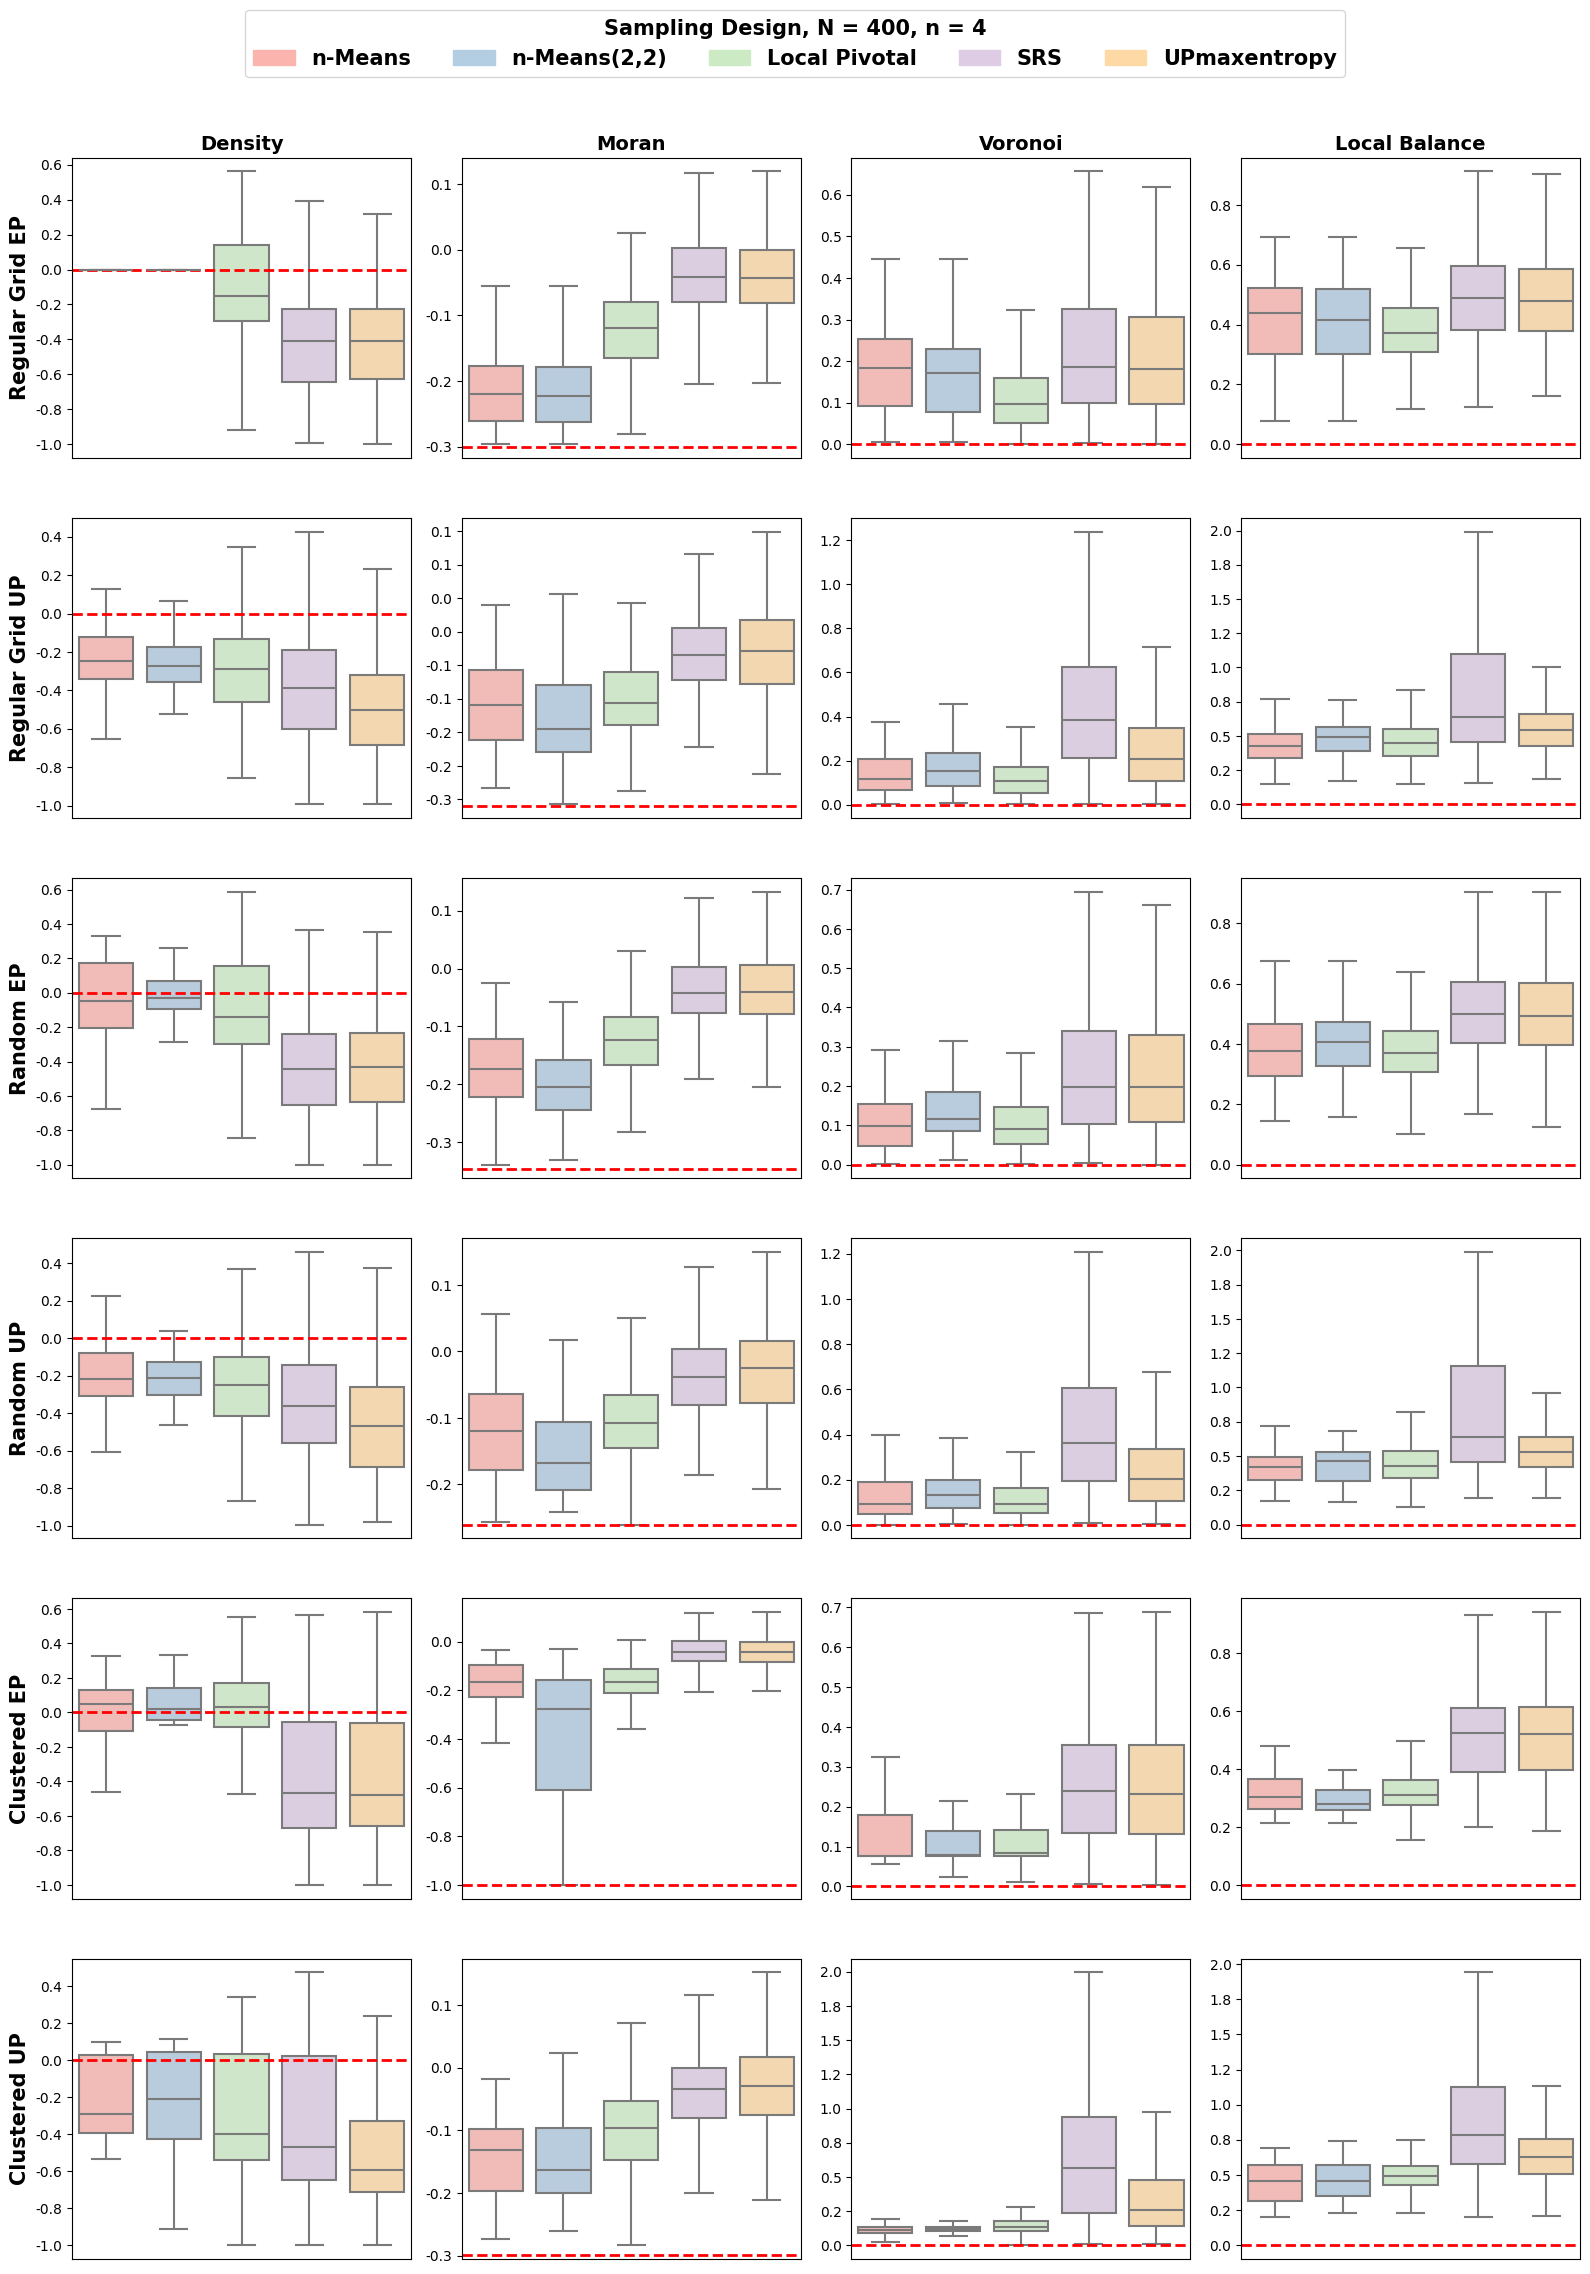

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')

# Folder and file info
method_order = ["n-Means", "n-Means(2,2)", "Local Pivotal", "SRS", "UPmaxentropy"]
results_folder = 'data_samples'
result_files = [
    "results_grid_eq.csv",
    "results_grid_uneq.csv",
    "results_random_eq.csv",
    "results_random_uneq.csv",
    "results_clust_eq.csv",
    "results_clust_uneq.csv",
    # "results_swiss_eq_n=10.csv",
    # "results_swiss_uneq_n=10.csv",
]
pretty_names = {
    "grid_eq": "Regular Grid Equal FIP",
    "grid_uneq": "Regular Grid Unequal FIP",
    "random_eq": "Random Equal FIP",
    "random_uneq": "Random Unequal FIP",
    "clust_eq": "Clustered Equal FIP",
    "clust_uneq": "Clustered Unequal FIP",
}

pretty_names = {
    "grid_eq": "Regular Grid EP",
    "grid_uneq": "Regular Grid UP",
    "random_eq": "Random EP",
    "random_uneq": "Random UP",
    "clust_eq": "Clustered EP",
    "clust_uneq": "Clustered UP",
}

# Use the new column for plotting (x or hue):
pop_names = [s.replace("results_", "").replace(".csv", "") for s in result_files]

# Read results into a dict
results_dict = {
    name: pd.read_csv(os.path.join(results_folder, fname))
    for name, fname in zip(pop_names, result_files)
}
# Mapping for nicer method names
method_name_mapping = {
    "K-Means (1, 1)": "n-Means",
    "K-Means (3, 3)": "n-Means(2,2)",
    "Local Pivotal": "Local Pivotal",
    "Random": "SRS",
    "UPmaxentropy": "UPmaxentropy"
}

# Apply the mapping to ALL dataframes in your results_dict
for df in results_dict.values():
    df["Method"] = df["Method"].map(method_name_mapping)

# OPTIONAL: Remove any 'Method Pretty' columns if you made them previously
for df in results_dict.values():
    if "Method Pretty" in df.columns:
        df.drop(columns=["Method Pretty"], inplace=True)
# Method palette for coloring
all_methods = pd.concat(list(results_dict.values()))["Method"].unique()
method_palette = dict(zip(all_methods, sns.color_palette("Pastel1", n_colors=len(all_methods))))

# Metrics
columns = [c for c in results_dict[pop_names[0]].columns if c != "Method"]
columns = [columns[i] for i in [0, 2, 1, 3]]

# Create 6x4 grid (6 populations, 4 metrics)
n_rows = len(pop_names)
n_cols = len(columns)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), sharey=False)

for row_idx, pop in enumerate(pop_names):
    df_pop = results_dict[pop]
    for col_idx, metric in enumerate(columns):
        ax = axes[row_idx, col_idx]
        sns.boxplot(
            x="Method",
            y=metric,
            data=df_pop[df_pop[metric] < 2],  # <--- Filter here!
#            data=df_pop, #remove_outliers(df_pop, metric, IQR_coef=10, groupby_col="Method"),
            hue="Method",  # always assign hue for consistent handles
            palette=method_palette,
            ax=ax,
            order=method_order,
            showfliers=False,
            linewidth=1.5,
            #boxprops=dict(color='black'),
            #whiskerprops=dict(color='black'),
            #capprops=dict(color='black'),
            #medianprops=dict(color='black'),
        )
        ax.tick_params(axis='x', length=0)  # This removes the little black lines (ticks) on the x-axis
        #ax.grid(True)
        if row_idx == 0:
            ax.set_title(f"{metric}", fontsize=14, weight='bold')
        else:
            ax.set_title("")
        if col_idx == 0:
            ax.set_ylabel(pretty_names.get(pop, pop), weight='bold', fontsize=15)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_xticklabels([])
        if not (row_idx == 0 and col_idx == 0):
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
        ax.tick_params(axis='y', labelsize=10)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))  # 2 decimals
        if metric in ['Density', 'Voronoi', 'Local Balance']:
            ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
        else:
            ax.axhline(y=min(df_pop['Moran']), color='red', linestyle='--', linewidth=2)
# ... rest of your code as above ...

# ----------- SHARED LEGEND BLOCK (robust dummy plot method) -----------
fig_legend, ax_legend = plt.subplots()
df_concat = pd.concat(list(results_dict.values()), ignore_index=True)

# NOTE: Only use x="Method", NOT hue!
sns.boxplot(
    x="Method",
    y=columns[0],
    data=df_concat,
    palette=method_palette,
    ax=ax_legend,
    showfliers=False
)
handles, labels = ax_legend.get_legend_handles_labels()

# If still empty, use get_xticklabels instead:
if all([h is None for h in handles]) or not handles:
    labels = [t.get_text() for t in ax_legend.get_xticklabels()]
    from matplotlib.patches import Patch
    handles = [Patch(color=method_palette[l]) for l in labels]

plt.close(fig_legend)
leg = fig.legend(
    handles, labels, loc='upper center', ncol=len(all_methods),
    title="Sampling Design, N = 400, n = 4",
    fontsize=15,              # Label size
    title_fontsize=15         # Title size
    # No fontweight argument directly here
)

# Make legend labels bold
for text in leg.get_texts():
    text.set_fontweight('bold')

# Make legend title bold
leg.get_title().set_fontweight('bold')
fig.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.subplots_adjust(wspace=0.15, hspace=0.2)
# fig.suptitle("All metrics for all populations", fontsize=16, y=1.01)
plt.show()

##### Swiss

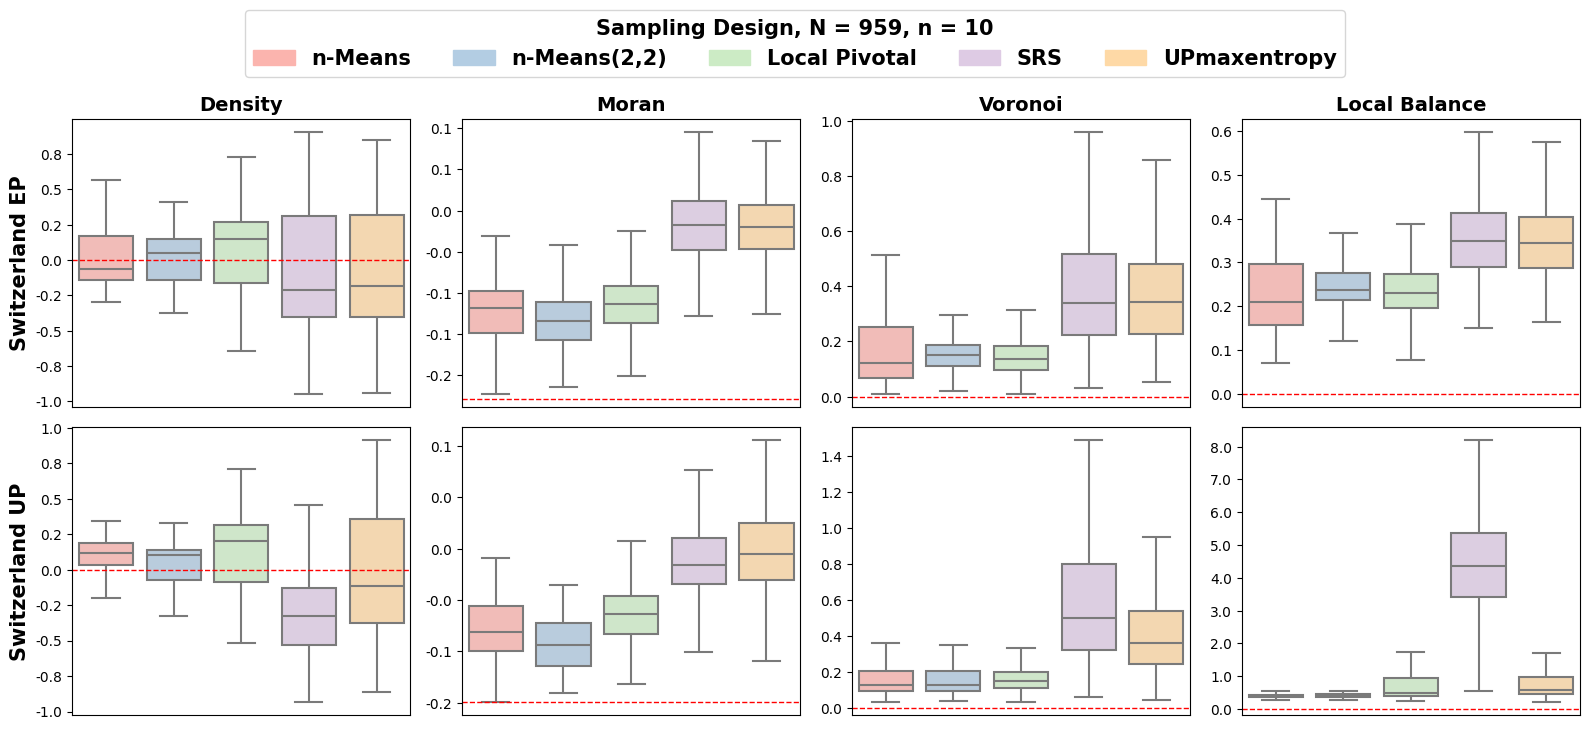

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')

# Folder and file info
method_order = ["n-Means", "n-Means(2,2)", "Local Pivotal", "SRS", "UPmaxentropy"]
results_folder = 'data_samples'
result_files = [
    "results_swiss_eq_n=10.csv",
    "results_swiss_uneq_n=10.csv",
]
pretty_names = {
    "swiss_eq_n=10": "Switzerland EP",
    "swiss_uneq_n=10": "Switzerland UP",
}

# Use the new column for plotting (x or hue):
pop_names = [s.replace("results_", "").replace(".csv", "") for s in result_files]

# Read results into a dict
results_dict = {
    name: pd.read_csv(os.path.join(results_folder, fname))
    for name, fname in zip(pop_names, result_files)
}
# Mapping for nicer method names
method_name_mapping = {
    "K-Means (1, 1)": "n-Means",
    "K-Means (2, 2)": "n-Means(2,2)",
    "Local Pivotal": "Local Pivotal",
    "Random": "SRS",
    "UPmaxentropy": "UPmaxentropy"
}

# Apply the mapping to ALL dataframes in your results_dict
for df in results_dict.values():
    df["Method"] = df["Method"].map(method_name_mapping)

# OPTIONAL: Remove any 'Method Pretty' columns if you made them previously
for df in results_dict.values():
    if "Method Pretty" in df.columns:
        df.drop(columns=["Method Pretty"], inplace=True)
# Method palette for coloring
all_methods = pd.concat(list(results_dict.values()))["Method"].unique()
method_palette = dict(zip(all_methods, sns.color_palette("Pastel1", n_colors=len(all_methods))))


# Metrics
columns = [c for c in results_dict[pop_names[0]].columns if c != "Method"]
columns = [columns[i] for i in [0, 2, 1, 3]]

# Create 6x4 grid (6 populations, 4 metrics)
n_rows = len(pop_names)
n_cols = len(columns)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), sharey=False)

for row_idx, pop in enumerate(pop_names):
    df_pop = results_dict[pop]
    for col_idx, metric in enumerate(columns):
        ax = axes[row_idx, col_idx]
        sns.boxplot(
            x="Method",
            y=metric,
            data=df_pop,#[df_pop[metric] < 2],  # <--- Filter here!
#            data=df_pop, #remove_outliers(df_pop, metric, IQR_coef=10, groupby_col="Method"),
            hue="Method",  # always assign hue for consistent handles
            palette=method_palette,
            ax=ax,
            order=method_order,
            showfliers=False,
            linewidth=1.5

        )
        #ax.grid(True)
        ax.tick_params(axis='x', length=0)  # This removes the little black lines (ticks) on the x-axis
        #ax.grid(True)
        if row_idx == 0:
            ax.set_title(f"{metric}", fontsize=14, weight='bold')
        else:
            ax.set_title("")
        if col_idx == 0:
            ax.set_ylabel(pretty_names.get(pop, pop), weight='bold', fontsize=15)
        else:
            ax.set_ylabel("")
        ax.set_xticklabels([])
        if not (row_idx == 0 and col_idx == 0):
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
        ax.tick_params(axis='y', labelsize=10)
        ax.set_xlabel("")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))  # 2 decimals
        if metric in ['Density', 'Voronoi', 'Local Balance']:
            ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
        else:
            ax.axhline(y=min(df_pop['Moran']), color='red', linestyle='--', linewidth=1)
# ... rest of your code as above ...

# ----------- SHARED LEGEND BLOCK (robust dummy plot method) -----------
fig_legend, ax_legend = plt.subplots()
df_concat = pd.concat(list(results_dict.values()), ignore_index=True)

# NOTE: Only use x="Method", NOT hue!
sns.boxplot(
    x="Method",
    y=columns[0],
    data=df_concat,
    palette=method_palette,
    ax=ax_legend,
    showfliers=False
)
handles, labels = ax_legend.get_legend_handles_labels()

# If still empty, use get_xticklabels instead:
if all([h is None for h in handles]) or not handles:
    labels = [t.get_text() for t in ax_legend.get_xticklabels()]
    from matplotlib.patches import Patch
    handles = [Patch(color=method_palette[l]) for l in labels]

plt.close(fig_legend)

leg = fig.legend(
    handles, labels, loc='upper center', ncol=len(all_methods),
    title="Sampling Design, N = 959, n = 10",
    fontsize=15,              # Label size
    title_fontsize=15         # Title size
    # No fontweight argument directly here
)

# Make legend labels bold
for text in leg.get_texts():
    text.set_fontweight('bold')

# Make legend title bold
leg.get_title().set_fontweight('bold')

# ----------------------------------------------------------------------
fig.tight_layout(rect=[0, 0.08, 1, 1])  # Increase lower value (0.05→0.08)
fig.subplots_adjust(top=0.85)  # Fine tune if title/legend crowds# fig.suptitle("All metrics for all populations", fontsize=16, y=1.01)
plt.show()

In [ ]:
len(probs)

NameError: name 'probs' is not defined

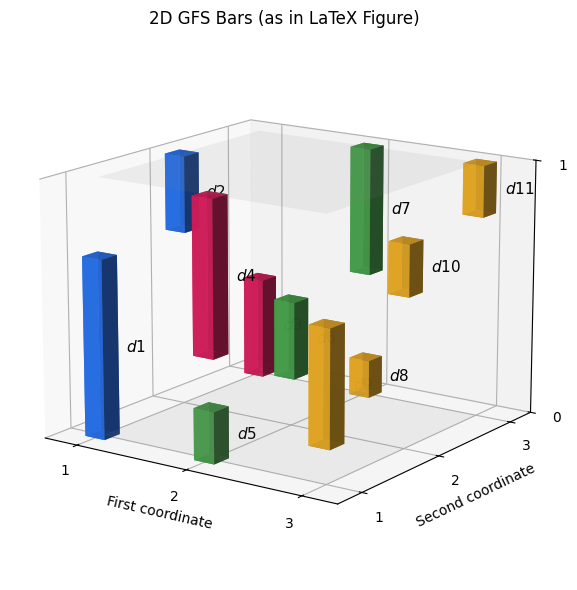

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

bars_3d = [
    # x, y, z_start, z_end, label, color
    (1, 1, 0.0, 0.7, 'd1', 'myblue'),
    (1, 2, 0.7, 1.0, 'd2', 'myblue'),
    (1, 3, 0.0, 0.4, 'd3', 'myred'),
    (2, 1, 0.4, 1.0, 'd4', 'myred'),
    (2, 1, 0.0, 0.2, 'd5', 'mygreen'),
    (2, 2, 0.2, 0.5, 'd6', 'mygreen'),
    (2, 3, 0.5, 1.0, 'd7', 'mygreen'),
    (2, 3, 0.0, 0.15, 'd8', 'mygold'),
    (3, 1, 0.15, 0.6, 'd9', 'mygold'),
    (3, 2, 0.6, 0.8, 'd10', 'mygold'),
    (3, 3, 0.8, 1.0, 'd11', 'mygold'),
]

color_dict = {
    "myblue": "#2979FF",
    "myred": "#E91E63",
    "mygreen": "#4CAF50",
    "mygold": "#FDB827",
    "mypurple": "#9C27B0",
}

fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(111, projection='3d')

dx = dy = 0.18  # bar thickness

for (x, y, z1, z2, label, cgroup) in bars_3d:
    height = z2 - z1
    ax.bar3d(x - dx/2, y - dy/2, z1, dx, dy, height, color=color_dict[cgroup], alpha=0.85)
    ax.text(x + dx/2 + 0.07, y + dy/2, (z1+z2)/2, f"${label}$", fontsize=11, va='center', ha='left')

# Draw "floors" at z=0 and z=1
for z, alpha in [(0, 0.1), (1, 0.1)]:
    X, Y = np.meshgrid([1,2,3], [1,2,3])
    Z = np.full_like(X, z)
    ax.plot_surface(X, Y, Z, color='gray', alpha=alpha, shade=False)

ax.set_xlim(0.7,3.3)
ax.set_ylim(0.7,3.3)
ax.set_zlim(0,1)
ax.set_xlabel("First coordinate")
ax.set_ylabel("Second coordinate")
ax.set_zlabel("Inclusion Probabilities")
ax.set_xticks([1,2,3])
ax.set_yticks([1,2,3])
ax.set_zticks([0,1])
ax.view_init(elev=15, azim=-55)
ax.set_title("2D GFS Bars (as in LaTeX Figure)")

plt.tight_layout()
plt.show()

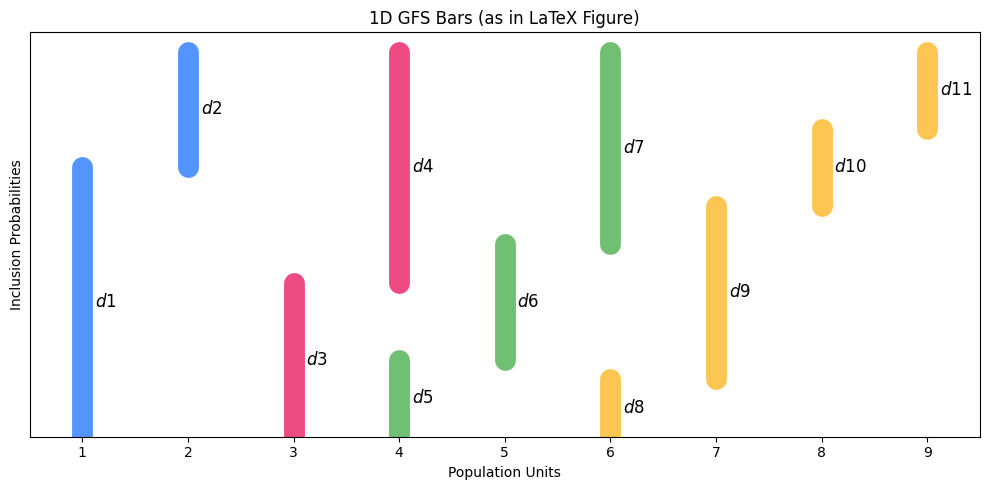

In [ ]:
import matplotlib.pyplot as plt

# Coordinates for each bar segment: (x, y_start, y_end, label)
bars = [
    (1, 0.0, 0.7, 'd1', 'myblue'),
    (2, 0.7, 1.0, 'd2', 'myblue'),
    (3, 0.0, 0.4, 'd3', 'myred'),
    (4, 0.4, 1.0, 'd4', 'myred'),
    (4, 0.0, 0.2, 'd5', 'mygreen'),
    (5, 0.2, 0.5, 'd6', 'mygreen'),
    (6, 0.5, 1.0, 'd7', 'mygreen'),
    (6, 0.0, 0.15, 'd8', 'mygold'),
    (7, 0.15, 0.6, 'd9', 'mygold'),
    (8, 0.6, 0.8, 'd10', 'mygold'),
    (9, 0.8, 1.0, 'd11', 'mygold'),
]

color_dict = {
    "myblue": "#2979FF",
    "myred": "#E91E63",
    "mygreen": "#4CAF50",
    "mygold": "#FDB827",
    "mypurple": "#9C27B0",
}

fig, ax = plt.subplots(figsize=(10, 5))

for (x, y1, y2, label, cgroup) in bars:
    ax.plot([x, x], [y1, y2], color=color_dict[cgroup], lw=15, alpha=0.8, solid_capstyle='round')
    ax.text(x+0.12, (y1+y2)/2, f"${label}$", va='center', fontsize=12)

ax.set_xlim(0.5, 9.5)
ax.set_ylim(0, 1.05)
ax.set_xticks(range(1, 10))
ax.set_yticks([])
ax.set_xlabel("Population Units")
ax.set_ylabel("Inclusion Probabilities")
ax.grid(axis='y', linestyle='dashed', alpha=0.5)
ax.set_title("1D GFS Bars (as in LaTeX Figure)")

plt.tight_layout()
plt.show()